In [1]:
import pandas as pd

In [2]:
true = pd.read_csv('True.csv')

In [3]:
true.head(3)

,title,text
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...


In [4]:
fake = pd.read_csv('Fake.csv')
fake = fake.iloc[:,0:2]

C:\Users\rosha\AppData\Local\Temp\ipykernel_16564\3660637155.py:1: DtypeWarning: Columns (2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149) have mixed types. Specify dtype option on import or set low_memory=False.
  fake = pd.read_csv('Fake.csv')


In [5]:
fake.head(3)

,title,text
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk..."


In [6]:
true.shape

(21417, 2)

In [7]:
fake.shape

(23565, 2)

In [8]:
true['label'] = 1

In [9]:
true.head(3)

,title,text,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,1


In [10]:
fake['label'] = 0

In [11]:
fake.head(3)

,title,text,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",0


In [12]:
frames = [true.loc[0:5000][:], fake.loc[0:5000][:]]
df = pd.concat(frames)

In [13]:
df.shape

(10002, 3)

In [14]:
df = df.sample(frac=1).reset_index(drop=True)

In [15]:
df.head()

,title,text,label
0,Dan Rather SHREDS Wall Street Journal For Dod...,"Yesterday, the Wall Street Journal s editor-in...",0
1,Meghan McCain Tweets The Most AMAZING Respons...,As a Democrat won a Senate seat in deep-red Al...,0
2,Trump says Senate Republicans likely to pass h...,WASHINGTON (Reuters) - U.S. President Donald T...,1
3,CNN Host STUNNED As Trump Supporter Says Vote...,As Donald Trump and his supporters continue to...,0
4,Trump met Stanford's John Taylor in Fed chair ...,WASHINGTON (Reuters) - President Donald Trump ...,1


In [16]:
X = df.drop('label', axis=1)

In [17]:
y = df['label']

In [18]:
df = df.dropna()

In [19]:
messages = df.copy()

In [20]:
messages.reset_index(inplace=True)

In [21]:
messages.head()

,index,title,text,label
0,0,Dan Rather SHREDS Wall Street Journal For Dod...,"Yesterday, the Wall Street Journal s editor-in...",0
1,1,Meghan McCain Tweets The Most AMAZING Respons...,As a Democrat won a Senate seat in deep-red Al...,0
2,2,Trump says Senate Republicans likely to pass h...,WASHINGTON (Reuters) - U.S. President Donald T...,1
3,3,CNN Host STUNNED As Trump Supporter Says Vote...,As Donald Trump and his supporters continue to...,0
4,4,Trump met Stanford's John Taylor in Fed chair ...,WASHINGTON (Reuters) - President Donald Trump ...,1


In [22]:
messages['title'][2]

'Trump says Senate Republicans likely to pass healthcare bill'

In [23]:
messages['text'][2]

'WASHINGTON (Reuters) - U.S. President Donald Trump on Wednesday expressed confidence that the Republican-led Senate would ultimately prevail in  passing legislation aimed at repealing and replacing the 2010 healthcare law passed under his predecessor, former Democratic president Barack Obama. “It’s very tough ... I think we’re going to get it over the line,” Trump told reporters at the White House ahead of a separate event on energy, adding that healthcare was “probably the toughest subject” to get passed in Congress.  '

### Preprocessing

In [24]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [ ]:
import re
import nltk
nltk.download('stopwords')

corpus = []
for i in range(0, len(messages)):
    review = re.sub('[^a-zA-Z]', ' ', messages['text'][i])
    review = review.lower()
    review = review.split()
    
    review = [ps.stem(word) for word in review if not word in stopwords.words('english')]
    review = ' '.join(review)
    corpus.append(review)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rosha\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [ ]:
len(corpus)

10002

In [ ]:
## TFidf Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_v = TfidfVectorizer(max_features=5000, ngram_range=(1,3))

In [ ]:
tfidf_v.get_params()

{'analyzer': 'word',
 'binary': False,
 'decode_error': 'strict',
 'dtype': numpy.float64,
 'encoding': 'utf-8',
 'input': 'content',
 'lowercase': True,
 'max_df': 1.0,
 'max_features': 5000,
 'min_df': 1,
 'ngram_range': (1, 3),
 'norm': 'l2',
 'preprocessor': None,
 'smooth_idf': True,
 'stop_words': None,
 'strip_accents': None,
 'sublinear_tf': False,
 'token_pattern': '(?u)\\b\\w\\w+\\b',
 'tokenizer': None,
 'use_idf': True,
 'vocabulary': None}

In [ ]:
X = tfidf_v.fit_transform(corpus).toarray()
y = messages['label']

In [ ]:
## Divide the dataset into Train and Test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [ ]:
count_df = pd.DataFrame(X_train, columns=tfidf_v.get_feature_names_out())
count_df.head(3)

,abandon,abc,abc news,abe,abil,abl,abort,abroad,absolut,absurd,...,york reuter,york time,york time report,young,young peopl,younger,youtub,zero,zink,zone
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.045102,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Passive Aggressive Classifier - Baseline

In [ ]:
from sklearn.linear_model import PassiveAggressiveClassifier
classifier = PassiveAggressiveClassifier(max_iter=1000)

In [ ]:
from sklearn import metrics
import numpy as np
import itertools

classifier.fit(X_train, y_train)

pred = classifier.predict(X_test)

score = metrics.accuracy_score(y_test, pred)
print("accuracy:   %0.3f" % score)

accuracy:   1.000


In [ ]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    See full source and example: 
    http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html
    
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

Confusion matrix, without normalization


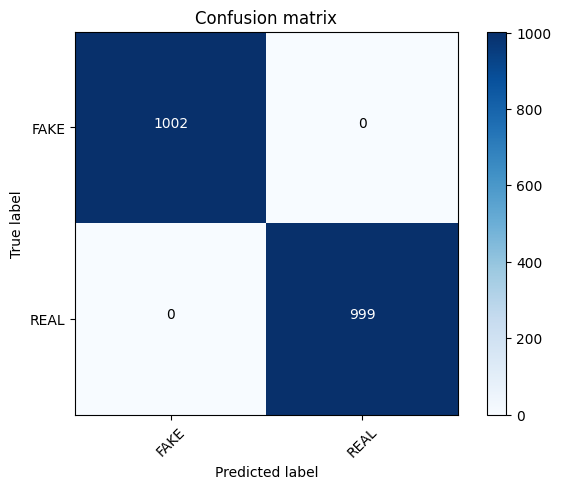

In [ ]:
cm = metrics.confusion_matrix(y_test, pred)
plot_confusion_matrix(cm, classes=['FAKE', 'REAL'])

In [ ]:
classifier.predict(X_test)

array([0, 0, 1, ..., 0, 1, 0], dtype=int64)

### Preprocess and transform datapoint text (true['text'][16888]) and try to predict it based on the model

In [ ]:
review = re.sub('[^a-zA-Z]', ' ', true['text'][16888])
review = review.lower()
review = review.split()
    
review = [ps.stem(word) for word in review if not word in stopwords.words('english')]
review = ' '.join(review)
review

'cairo reuter three polic offic kill eight other injur shoot raid suspect milit hideout giza southwest egyptian capit two secur sourc said friday sourc said author follow lead apart thought hous eight suspect member hasm group claim sever attack around capit target judg policemen sinc last year suspect milit fled exchang fire sourc said egypt accus hasm milit wing muslim brotherhood islamist group outlaw muslim brotherhood deni islamist insurg sinai peninsula grown sinc militari overthrew presid moham mursi muslim brotherhood mid follow mass protest rule milit group stage insurg pledg allegi islam state blame kill hundr soldier policemen start target area includ egypt christian copt'

In [ ]:
val = tfidf_v.transform([review]).toarray()

In [ ]:
pd.DataFrame(val, columns=tfidf_v.get_feature_names_out())

,abandon,abc,abc news,abe,abil,abl,abort,abroad,absolut,absurd,...,york reuter,york time,york time report,young,young peopl,younger,youtub,zero,zink,zone
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
classifier.predict(val)

array([1], dtype=int64)